In [ ]:
import warnings
import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import BoundaryNorm
import matplotlib.colors

from metpy.plots import USCOUNTIES
import cmocean

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

import calendar
from tqdm.auto import tqdm
from dask.diagnostics import ProgressBar

warnings.filterwarnings("ignore")


# Display Formatting
def clean_fmt(x, pos):
    # if integer, print without .0
    if float(x).is_integer():
        return f"{int(x)}"
    # otherwise print a trimmed float
    return f"{x:.2f}".rstrip('0').rstrip('.')

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 200      # notebook display

In [ ]:
# 1. Define region of interest - (South Florida Extent)

lon_min = -83
lon_max = -79.85
lat_min = 28.5
lat_max = 24.5

LON_SLICE = slice(lon_min, lon_max)
LAT_SLICE = slice(lat_min, lat_max)
BASE_DIR = '/bkirtman/tphoa'

def adjust_coords(ds, rename_time=False):
    if rename_time and 'Time' in ds.dims:
        ds = ds.rename({'Time': 'time'})
        
    # Standardize longitude to -180 to 180
    if ds.lon.max() > 180:
        ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180)).sortby("lon")
    
    return ds.sel(lon=LON_SLICE, lat=LAT_SLICE)

# 2. Load and process datasets, convert to mm/day
# Observational/Reference Data
ds_nclimgrid = adjust_coords(xr.open_mfdataset(f'{BASE_DIR}/nclimgrid/nclimgrid-daily-prcp.*.nc'))

ds_imerg     = xr.open_mfdataset(f'{BASE_DIR}/imerg/year/precip_*_FL.nc4').transpose("time", "lat", "lon")
ds_imerg = ds_imerg.where(ds_nclimgrid['prcp'].notnull().any(dim='time').astype(float).interp(lon=ds_imerg.lon, lat=ds_imerg.lat, method='nearest') > 0)

ds_livneh    = adjust_coords(xr.open_mfdataset(f'{BASE_DIR}/LOCA-train/livneh-2015.prec.*.nc'))

# ds_pierce: renaming Time -> time
ds_pierce    = adjust_coords(xr.open_mfdataset(f'{BASE_DIR}/LOCA-train/livneh_unsplit_precip.*.nc'), rename_time=True)

# CCSM4 & CESM2 (Historical)
ds_ccsm4     = adjust_coords(xr.open_mfdataset(f'{BASE_DIR}/cesm/pr_day_CCSM4_historical_r6i1p1_*.nc')) * 86400.0

ds_cesm2_lens = xr.open_mfdataset(f'{BASE_DIR}/cesm/b.e21.BHISTcmip6.f09_g17.LE2-*.cam.h1.PRECT.1950-2014.nc', 
                                 concat_dim="ensemble", combine="nested", decode_times=True)
# ds_cesm2_lens unit conversion (m/s to mm/day)
ds_cesm2_lens = adjust_coords(ds_cesm2_lens) * 1000 * 86400.0

# LOCA Data
ds_loca_ccsm4 = adjust_coords(xr.open_dataset(f'{BASE_DIR}/LOCA/pr.CCSM4.historical.r6i1p1f1.1950-2005.LOCA_16thdeg.s_FL.nc'))

ds_loca_cesm2 = adjust_coords(xr.open_mfdataset(f'{BASE_DIR}/LOCA/pr.CESM2-LENS.historical.r*i1p1f1.1950-2014.LOCA_16thdeg_v20240915.s_east.nc',
                                                concat_dim="ensemble", combine="nested", decode_times=True)) 
ds_loca_cesm2 = ds_loca_cesm2 * 86400.0

In [ ]:
# ============================================================
# Subset common analysis period
# ============================================================

TIME_SLICE = slice("1951-01-01", "2014-12-31")

ds_nclimgrid    = ds_nclimgrid.sel(time=TIME_SLICE)
ds_imerg        = ds_imerg.sel(time=TIME_SLICE)
ds_livneh       = ds_livneh.sel(time=TIME_SLICE)
ds_pierce       = ds_pierce.sel(time=TIME_SLICE)

ds_ccsm4        = ds_ccsm4.sel(time=TIME_SLICE)
ds_cesm2_lens   = ds_cesm2_lens.sel(time=TIME_SLICE)

ds_loca_ccsm4   = ds_loca_ccsm4.sel(time=TIME_SLICE)
ds_loca_cesm2   = ds_loca_cesm2.sel(time=TIME_SLICE)

## Fig. 3a Month of Annual Rx1day occurs (Single Day)

In [ ]:
# nClimGrid
date_of_max_nclimgrid   = ds_nclimgrid['prcp'].idxmax(dim='time')
month_of_max_nclimgrid  = date_of_max_nclimgrid.dt.month.compute()

# GPM IMERG V7
date_of_max_imerg  = ds_imerg['precipitation'].idxmax(dim='time')
month_of_max_imerg = date_of_max_imerg.dt.month.compute()

# LOCA-CCSM4
date_of_max_ccsm4   = ds_loca_ccsm4['pr'].idxmax(dim='time')
month_of_max_ccsm4  = date_of_max_ccsm4.dt.month.compute()

# LOCA-CESM2-LENS
pr_max_ens     = ds_loca_cesm2['pr'].max(dim='ensemble')
all_nan        = pr_max_ens.isnull().all('time')
fill_val       = np.finfo(pr_max_ens.dtype).min
t_idx          = pr_max_ens.fillna(fill_val).argmax('time').compute()
wettest_date   = pr_max_ens['time'].isel(time=t_idx)
month_of_max_cesm2  = wettest_date.dt.month.where(~all_nan).compute()


months_da = [
    month_of_max_nclimgrid,
    month_of_max_imerg,
    month_of_max_ccsm4,
    month_of_max_cesm2
]

titles = [
    "nClimGrid-Daily",
    "IMERG V7",
    "LOCA-CCSM4",
    "LOCA-CESM2-LENS"
]

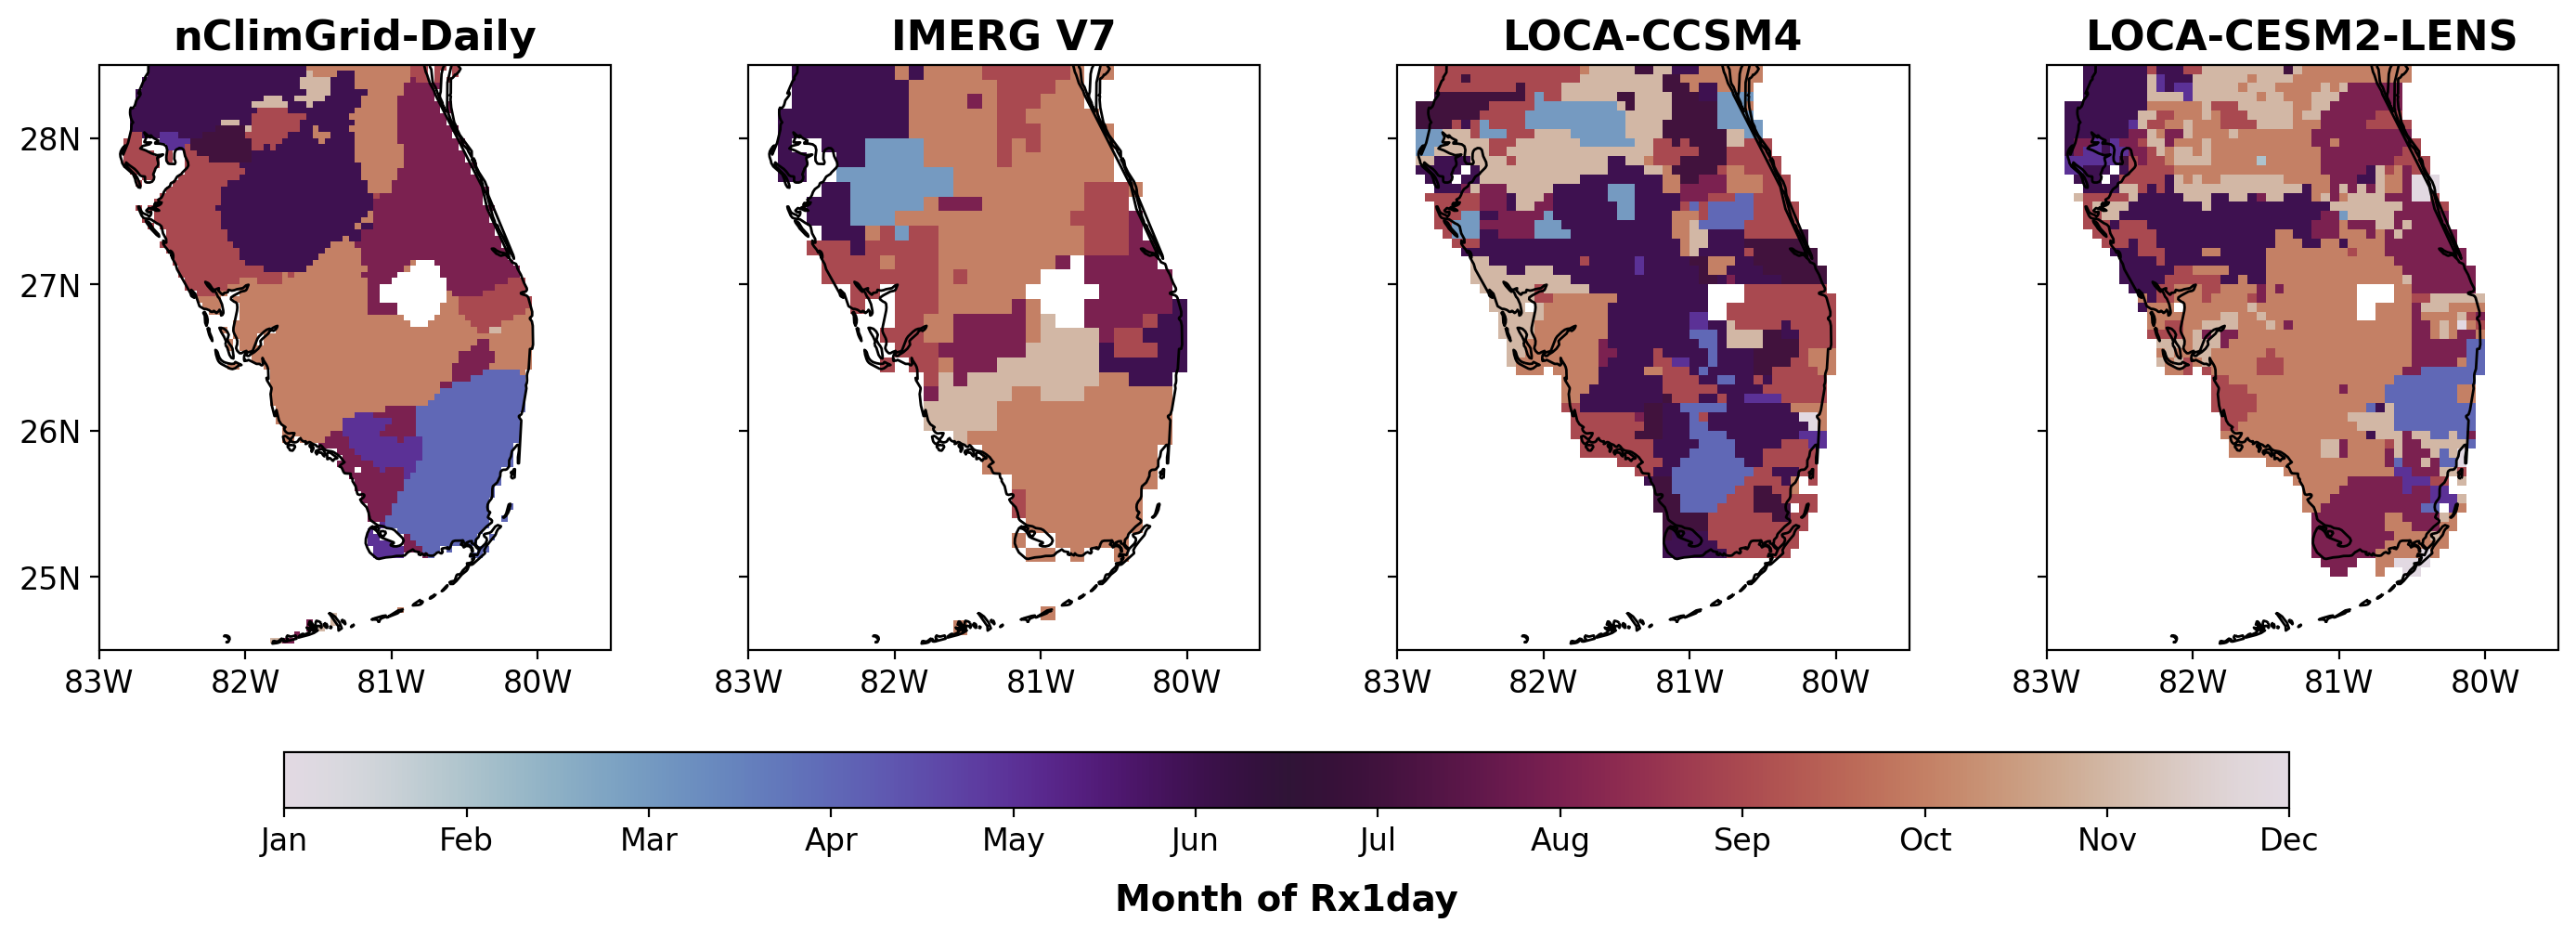

In [ ]:
fig, axes = plt.subplots(
    ncols=4,
    figsize=(18, 5),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
axes = axes.ravel()

for i, (ax, da, title) in enumerate(zip(axes, months_da, titles)):

    im = da.plot(
        ax=ax,
        x="lon", y="lat",
        cmap=cmap,
        vmin=1, vmax=12,
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.coastlines(resolution="10m")
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.xaxis.set_major_formatter(
        LongitudeFormatter(number_format='.0f', degree_symbol='', dateline_direction_label=False)
    )
    ax.yaxis.set_major_formatter(
        LatitudeFormatter(number_format='.0f', degree_symbol='')
    )

    ax.tick_params(labelsize=12)

    if i != 0:
        ax.set_yticklabels([])

cbar_ax = fig.add_axes([0.20, 0.08, 0.60, 0.06])

cbar = fig.colorbar(
    im,
    cax=cbar_ax,
    orientation="horizontal",
    ticks=np.arange(1, 13)
)

cbar.ax.xaxis.set_major_formatter(month_formatter)
cbar.set_label("Month of Rx1day", fontsize=14, labelpad=10, fontweight="bold")
cbar.ax.tick_params(labelsize=12)

plt.subplots_adjust(wspace=0.01, bottom=0.25)
plt.show()

## Fig. 3b Month of Annual Rx1day (By Frequency)

In [ ]:


def annual_max_time(sub):
    """Return datetime index of the max value within each year."""
    return sub.idxmax("time")

def most_freq_rx1day_month_single(ds, var, valid_threshold=0):
    """
    For a single-member dataset:
    1) compute monthly maxima
    2) find which month contains the annual maximum each year
    3) compute the most frequent month across years
    """
    da = ds[var]

    # monthly maxima
    monthly_max = da.resample(time="ME").max()

    # time of annual max from monthly maxima
    t_of_annual_max = monthly_max.groupby("time.year").map(annual_max_time)
    month_of_annual_max = t_of_annual_max.dt.month

    # count frequency of each month over years
    counts = xr.concat(
        [(month_of_annual_max == m).sum("year") for m in range(1, 13)],
        dim="month_cat"
    ).assign_coords(month_cat=np.arange(1, 13))

    most_freq_month = (counts.argmax("month_cat") + 1).rename("most_frequent_month")

    # mask cells with no precipitation through whole record
    valid_mask = da.max("time") > valid_threshold
    most_freq_month = most_freq_month.where(valid_mask)

    return most_freq_month


# ------------------------------------------------------------
# CESM2-LENS AND LOCA CESM2-LENS ONLY
# ------------------------------------------------------------
def most_freq_rx1day_month_ensemble(ds, var, member_dim="ensemble"):
    """
    For an ensemble dataset:
    1) compute monthly maxima for each member
    2) for each year/member/gridpoint, find month of annual max
    3) get most frequent month across years for each member
    4) take mode across ensemble members
    """
    da = ds[var]

    # monthly maxima, preserving ensemble dimension
    monthly_max = da.resample(time="ME").max()

    def month_of_yearly_max(sub):
        """
        sub dims after groupby year:
        typically (time, ensemble, lat, lon)
        returns month number (1..12) of yearly maximum
        """
        all_nan = sub.isnull().all("time")

        months = sub["time"].dt.month
        months = xr.broadcast(sub, months)[1]

        yearly_max = sub.max("time")
        is_max = sub == yearly_max

        month_at_max = months.where(is_max)
        out = month_at_max.max("time")   # resolves ties by latest month number

        return out.where(~all_nan)

    # (year, ensemble, lat, lon) or similar
    mon_ymax = monthly_max.groupby("time.year").map(month_of_yearly_max)

    # frequency over years for each ensemble member
    counts_ens_year = xr.concat(
        [(mon_ymax == m).sum("year") for m in range(1, 13)],
        dim="month_cat"
    ).assign_coords(month_cat=np.arange(1, 13))

    winner_per_ens = (counts_ens_year.argmax("month_cat") + 1).rename("most_frequent_month")

    # mode across ensemble members
    counts_ens = xr.concat(
        [(winner_per_ens == m).sum(member_dim) for m in range(1, 13)],
        dim="month_cat"
    ).assign_coords(month_cat=np.arange(1, 13))

    most_freq_month = (counts_ens.argmax("month_cat") + 1).rename("ensemble_mode_most_frequent_month")

    # mask cells that are NaN for all ensembles and all years
    mask = mon_ymax.isnull().all((member_dim, "year"))
    most_freq_month = most_freq_month.where(~mask)

    return most_freq_month

In [ ]:

most_freq_month_nclim = most_freq_rx1day_month_single(
    ds_nclimgrid, var="prcp"
).compute()

most_freq_month_imerg = most_freq_rx1day_month_single(
    ds_imerg, var="precipitation"   # change if needed
).compute()

most_freq_month_loca_ccsm4 = most_freq_rx1day_month_single(
    ds_loca_ccsm4, var="pr"
).compute()

most_freq_month_loca_cesm2 = most_freq_rx1day_month_ensemble(
    ds_loca_cesm2, var="pr", member_dim="ensemble"
).compute()

months_da_freq = [
    most_freq_month_nclim,
    most_freq_month_imerg,
    most_freq_month_loca_ccsm4,
    most_freq_month_loca_cesm2,
]



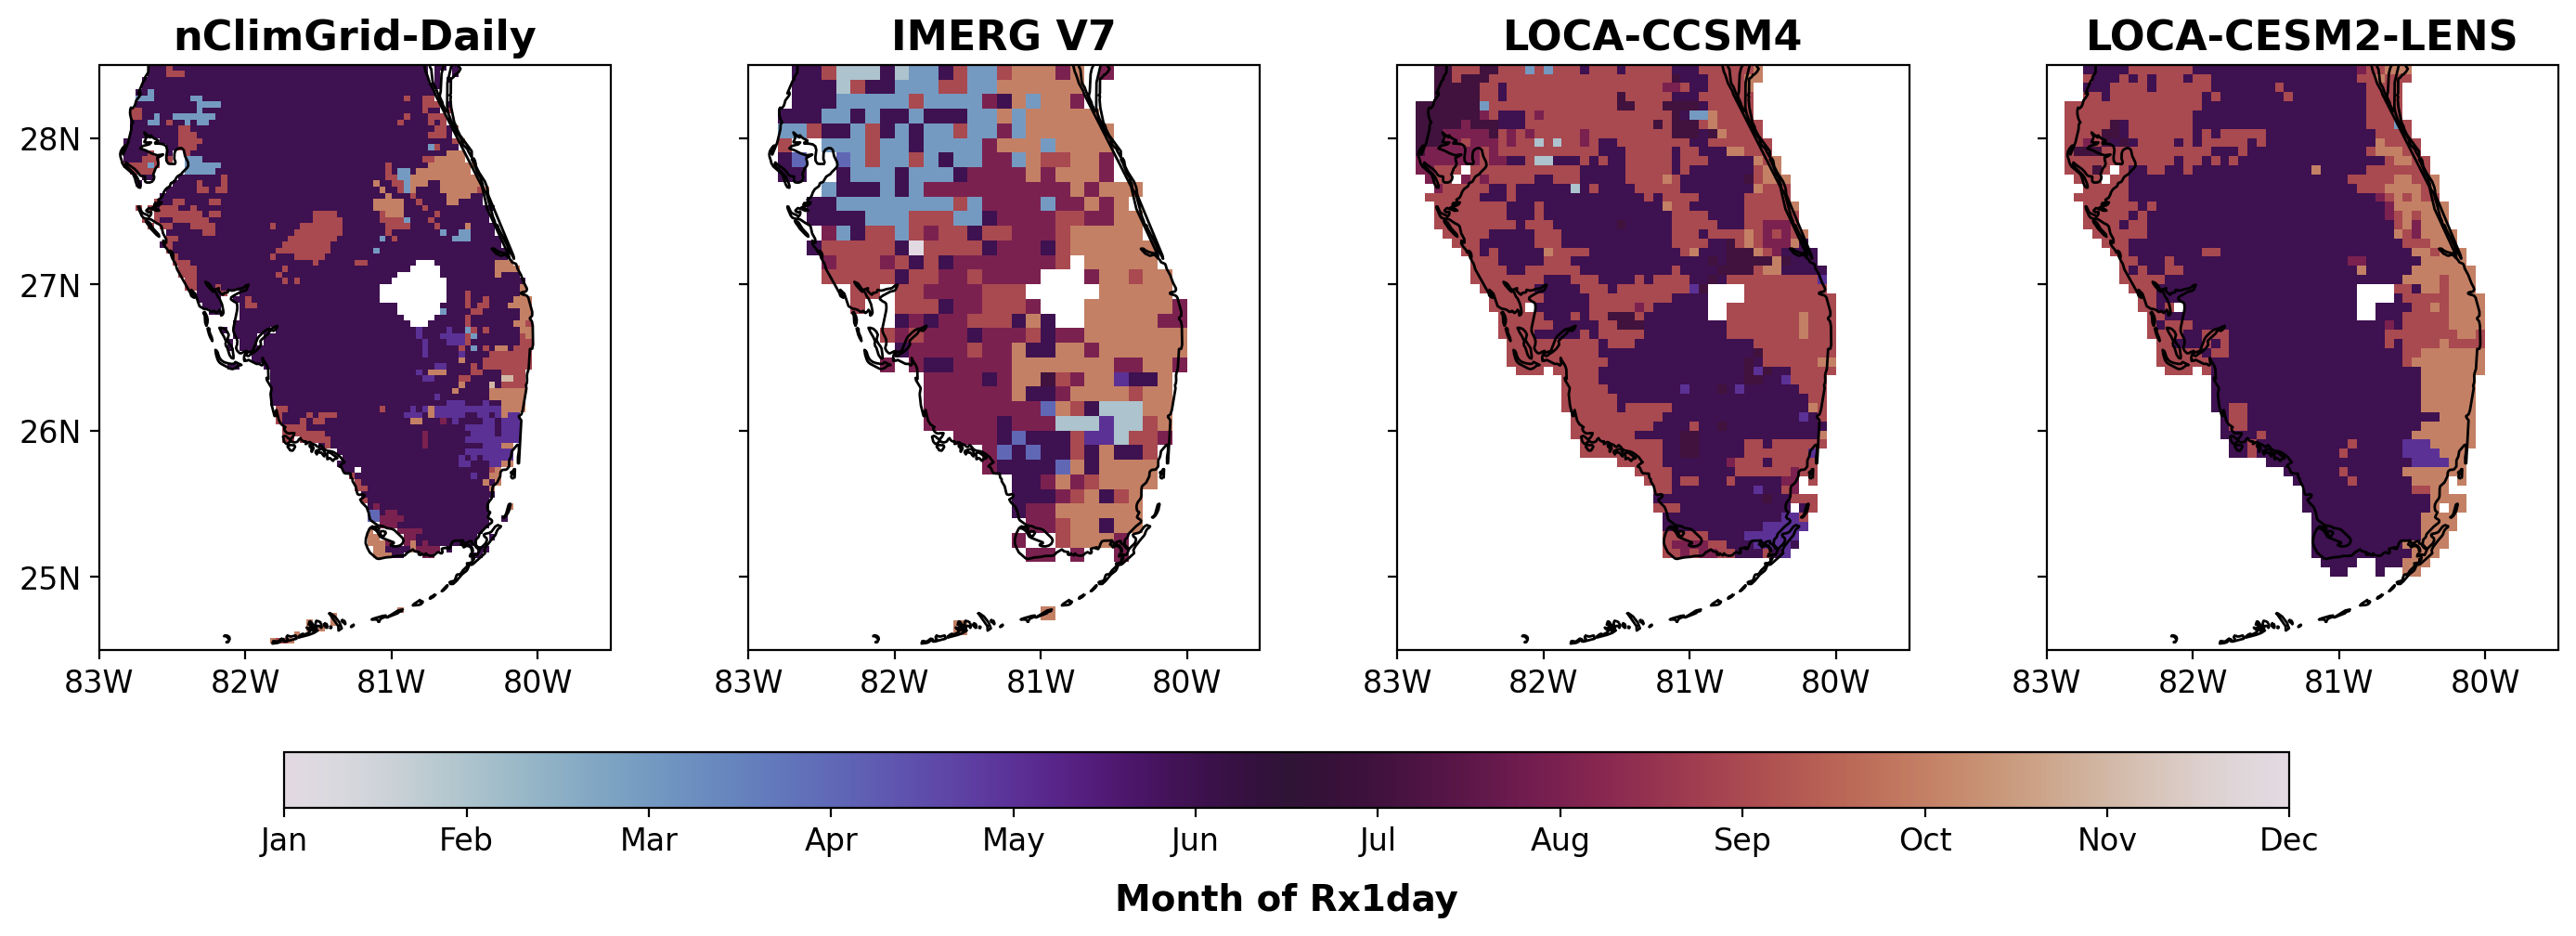

In [ ]:
titles = [
    "nClimGrid-Daily",
    "IMERG V7",
    "LOCA-CCSM4",
    "LOCA-CESM2-LENS"
]

lon_ticks = [-83, -82, -81, -80]
lat_ticks = [25, 26, 27, 28]


month_formatter = FuncFormatter(
    lambda v, p: calendar.month_abbr[int(v)] if 1 <= int(v) <= 12 else ""
)

cmap = plt.get_cmap("twilight")


fig, axes = plt.subplots(
    ncols=4,
    figsize=(18, 5),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
axes = axes.ravel()

for i, (ax, da, title) in enumerate(zip(axes, months_da_freq, titles)):

    im = da.plot(
        ax=ax,
        x="lon", y="lat",
        cmap=cmap,
        vmin=1, vmax=12,
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.coastlines(resolution="10m")
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.xaxis.set_major_formatter(
        LongitudeFormatter(number_format='.0f', degree_symbol='', dateline_direction_label=False)
    )
    ax.yaxis.set_major_formatter(
        LatitudeFormatter(number_format='.0f', degree_symbol='')
    )

    ax.tick_params(labelsize=12)

    if i != 0:
        ax.set_yticklabels([])

cbar_ax = fig.add_axes([0.20, 0.08, 0.60, 0.06])  # [left, bottom, width, height]

cbar = fig.colorbar(
    im,
    cax=cbar_ax,
    orientation="horizontal",
    ticks=np.arange(1, 13)
)

cbar.ax.xaxis.set_major_formatter(month_formatter)
cbar.set_label("Month of Rx1day", fontsize=14, labelpad=10, fontweight="bold")
cbar.ax.tick_params(labelsize=12)

plt.subplots_adjust(wspace=0.01, bottom=0.25)
plt.show()